# Provider personality traits over time

For each personality trait, plot the strength metric over time (release date) for Anthropic,
Gemini and OpenAI models. Each provider is one line; CI bounds (95% from `strength_with_stats`)
are shown as a faded fill around the line.

Mirrors the data-loading approach used in `02_plotting_paper.ipynb` (final table cell).

In [1]:
import importlib
import pathlib
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import feedback_forensics as ff
import feedback_forensics.app.plotting.paper as paper_plot

importlib.reload(paper_plot)
importlib.reload(ff)

fig_save_path = pathlib.Path("./output/png/traits_over_time")
fig_save_path.mkdir(parents=True, exist_ok=True)

# Same data file used in the final table cell of 02_plotting_paper.ipynb
data_path = pathlib.Path(
    "/Users/arduin/main/repos/huggingface/ff-model-personality/data/v2/annotations/combined_ap.json"
)

cache = {}
dataset = ff.DatasetHandler(cache=cache)
dataset.add_data_from_path(data_path)

📜  | INFO | AnnotatedPairs format version: 2.0
📜  | INFO | Removing 222 comparisons with empty responses. Fraction affected: 1.65%
📜  | INFO | Created 26454 annotations for 28 model annotators with 28 reference models in 0.13 seconds
📜  | INFO | Loaded data from path: /Users/arduin/main/repos/huggingface/ff-model-personality/data/v2/annotations/combined_ap.json


In [2]:
# Models to compare. Provider labels match the user-facing brand;
# release dates are best-effort approximations and can be edited as needed.
MODELS = {
    # --- Anthropic --------------------------------------------------------
    "openrouter/anthropic/claude-3.7-sonnet":   ("Anthropic", "2025-02-24"),
    "openrouter/anthropic/claude-sonnet-4":     ("Anthropic", "2025-05-22"),
    "openrouter/anthropic/claude-sonnet-4.5":   ("Anthropic", "2025-09-29"),
    #"openrouter/anthropic/claude-haiku-4.5":    ("Anthropic", "2025-10-15"),
    "openrouter/anthropic/claude-opus-4.7":     ("Anthropic", "2026-04-15"),
    # --- Google (Gemini) --------------------------------------------------
    "openrouter/google/gemini-2.5-pro":          ("Gemini",   "2025-03-25"),
    "openrouter/google/gemini-3-pro-preview":    ("Gemini",   "2025-11-18"),
    "openrouter/google/gemini-3.1-pro-preview":  ("Gemini",   "2026-04-15"),
    # --- OpenAI -----------------------------------------------------------
    #"openrouter/openai/gpt-3.5-turbo":           ("OpenAI",   "2022-11-30"),
    #"openrouter/openai/gpt-4.1-mini":            ("OpenAI",   "2025-04-14"),
    #"openrouter/openai/gpt-5":                   ("OpenAI",   "2025-08-07"),
    "openrouter/openai/gpt-5-chat":              ("OpenAI",   "2025-08-07"),
    #"openrouter/openai/gpt-5.1":                 ("OpenAI",   "2025-11-12"),
    "openrouter/openai/gpt-5.1-chat":            ("OpenAI",   "2025-11-12"),
    "openrouter/openai/gpt-5.3-chat":            ("OpenAI",   "2026-04-15"),
}

PROVIDERS = ["Anthropic", "OpenAI", "Gemini"]
PROVIDER_COLORS = {
    "Anthropic": "#D97757",  # warm orange
    "OpenAI":    "#10A37F",  # green
    "Gemini":    "#4285F4",  # blue
}

In [3]:
# Pick the model-identity annotators corresponding to MODELS and compute strength_with_stats
annotator_metadata = dataset.get_available_annotators()

selected_annotators = {
    annotator_key: meta
    for annotator_key, meta in annotator_metadata.items()
    if meta.get("model_id") in MODELS
}

missing_models = sorted(set(MODELS) - {m["model_id"] for m in selected_annotators.values()})
if missing_models:
    print("Warning: these models are not present as annotators in the dataset:")
    for m in missing_models:
        print("  -", m)

dataset.set_annotator_cols(annotator_keys=list(selected_annotators.keys()))

# Map column name (annotator_visible_name) -> model_id so we can look up provider/date
col_to_model = {
    meta["annotator_visible_name"]: meta["model_id"]
    for meta in selected_annotators.values()
}

df = dataset.get_annotator_metrics_df(
    metric_name="strength_with_stats",
    index_col_name="Generate a response that...",
)
df.head()

📜  | INFO | Setting annotator cols to ['Model: anthropic/claude-sonnet-4.5', 'Model: anthropic/claude-opus-4.7', 'Model: anthropic/claude-3.7-sonnet', 'Model: google/gemini-3.1-pro-preview', 'Model: google/gemini-3-pro-preview', 'Model: openai/gpt-5.3-chat', 'Model: openai/gpt-5.1-chat', 'Model: openai/gpt-5-chat', 'Model: google/gemini-2.5-pro', 'Model: anthropic/claude-sonnet-4']
📜  | WARNING | Reference annotator column '359d7a6d' contains values other than 'text_a' or 'text_b' (Values: Not applicable, text_a). Metrics will be computed on the subset of votes where the reference annotator is 'text_a' or 'text_b'.
📜  | WARNING | Reference annotator column 'c869561c' contains values other than 'text_a' or 'text_b' (Values: Not applicable, text_a). Metrics will be computed on the subset of votes where the reference annotator is 'text_a' or 'text_b'.
📜  | WARNING | Reference annotator column '81ea1afa' contains values other than 'text_a' or 'text_b' (Values: Not applicable, text_a). Metr

,Generate a response that...,Model: anthropic/claude-sonnet-4.5,Model: anthropic/claude-opus-4.7,Model: anthropic/claude-3.7-sonnet,Model: google/gemini-3.1-pro-preview,Model: google/gemini-3-pro-preview,Model: openai/gpt-5.3-chat,Model: openai/gpt-5.1-chat,Model: openai/gpt-5-chat,Model: google/gemini-2.5-pro,Model: anthropic/claude-sonnet-4,Max diff
is more verbose,is more verbose,"{'strength': -0.04016064257028109, 'hide_metri...","{'strength': 0.0903614457831325, 'hide_metrics...","{'strength': -0.2616632860040568, 'hide_metric...","{'strength': 0.5865580448065174, 'hide_metrics...","{'strength': 0.38492871690427705, 'hide_metric...","{'strength': -0.582, 'hide_metrics': False, 'p...","{'strength': -0.848, 'hide_metrics': False, 'p...","{'strength': 0.23200000000000007, 'hide_metric...","{'strength': 0.7439999999999999, 'hide_metrics...","{'strength': 0.0879999999999999, 'hide_metrics...",1.592
has more structured formatting,has more structured formatting,"{'strength': 0.19277108433734946, 'hide_metric...","{'strength': 0.30321285140562254, 'hide_metric...","{'strength': -0.21095334685598377, 'hide_metri...","{'strength': 0.4989816700610999, 'hide_metrics...","{'strength': 0.5336048879837068, 'hide_metrics...","{'strength': -0.47000000000000003, 'hide_metri...","{'strength': -0.628, 'hide_metrics': False, 'p...","{'strength': 0.422, 'hide_metrics': False, 'p_...","{'strength': 0.6980000000000001, 'hide_metrics...","{'strength': 0.04800000000000004, 'hide_metric...",1.326
is more concise,is more concise,"{'strength': 0.01606425702811245, 'hide_metric...","{'strength': -0.036144578313253024, 'hide_metr...","{'strength': 0.1703853955375254, 'hide_metrics...","{'strength': -0.2708757637474542, 'hide_metric...","{'strength': -0.18533604887983704, 'hide_metri...","{'strength': 0.48599999999999993, 'hide_metric...","{'strength': 0.792, 'hide_metrics': False, 'p_...","{'strength': -0.168, 'hide_metrics': False, 'p...","{'strength': -0.45399999999999996, 'hide_metri...","{'strength': -0.06799999999999998, 'hide_metri...",1.246
uses more bold and italics text,uses more bold and italics text,"{'strength': 0.3172690763052208, 'hide_metrics...","{'strength': 0.33935742971887556, 'hide_metric...","{'strength': -0.4219066937119675, 'hide_metric...","{'strength': 0.6822810590631365, 'hide_metrics...","{'strength': 0.6517311608961304, 'hide_metrics...","{'strength': -0.43, 'hide_metrics': False, 'p_...","{'strength': -0.498, 'hide_metrics': False, 'p...","{'strength': 0.692, 'hide_metrics': False, 'p_...","{'strength': 0.712, 'hide_metrics': False, 'p_...","{'strength': 0.10800000000000008, 'hide_metric...",1.210
provides more examples,provides more examples,"{'strength': 0.13855421686746983, 'hide_metric...","{'strength': 0.21285140562248997, 'hide_metric...","{'strength': -0.127789046653144, 'hide_metrics...","{'strength': 0.3543788187372709, 'hide_metrics...","{'strength': 0.3034623217922606, 'hide_metrics...","{'strength': -0.13799999999999998, 'hide_metri...","{'strength': -0.312, 'hide_metrics': False, 'p...","{'strength': 0.13799999999999998, 'hide_metric...","{'strength': 0.5399999999999999, 'hide_metrics...","{'strength': 0.13799999999999996, 'hide_metric...",0.852


In [4]:
# Reshape into a long-form table: one row per (trait, model)
records = []
for _, row in df.iterrows():
    trait = row["Generate a response that..."]
    for col_name, cell in row.items():
        if col_name in ("Generate a response that...", "Max diff"):
            continue
        if not isinstance(cell, dict):
            continue
        model_id = col_to_model.get(col_name)
        if model_id is None or model_id not in MODELS:
            continue
        provider, date = MODELS[model_id]
        records.append(
            {
                "trait": trait,
                "provider": provider,
                "model_id": model_id,
                "model_short": model_id.split("/")[-1],
                "date": pd.Timestamp(date),
                "strength": cell.get("strength"),
                "ci_lower": cell.get("ci_lower_95"),
                "ci_upper": cell.get("ci_upper_95"),
                "p_value": cell.get("p_value"),
            }
        )

records_df = pd.DataFrame(records)
print(f"Traits: {records_df['trait'].nunique()} | rows: {len(records_df)}")
records_df.head()

Traits: 40 | rows: 400


,trait,provider,model_id,model_short,date,strength,ci_lower,ci_upper,p_value
0,is more verbose,Anthropic,openrouter/anthropic/claude-sonnet-4.5,claude-sonnet-4.5,2025-09-29,-0.040161,-0.125749,0.043912,1.929191e-01
1,is more verbose,Anthropic,openrouter/anthropic/claude-opus-4.7,claude-opus-4.7,2026-04-15,0.090361,0.003992,0.175649,2.147338e-02
2,is more verbose,Anthropic,openrouter/anthropic/claude-3.7-sonnet,claude-3.7-sonnet,2025-02-24,-0.261663,-0.342742,-0.177419,1.071770e-09
3,is more verbose,Gemini,openrouter/google/gemini-3.1-pro-preview,gemini-3.1-pro-preview,2026-04-15,0.586558,0.512146,0.649798,2.548072e-43
4,is more verbose,Gemini,openrouter/google/gemini-3-pro-preview,gemini-3-pro-preview,2025-11-18,0.384929,0.303644,0.459514,1.125563e-18


In [5]:
def plot_trait(trait_name, trait_df, save_dir=fig_save_path, show=True):
    """Single-trait plot: strength over time per provider with CI fill."""
    fig, ax = plt.subplots(figsize=(8, 4.5))

    for provider in PROVIDERS:
        sub = (
            trait_df[trait_df["provider"] == provider]
            .dropna(subset=["strength"])
            .sort_values("date")
        )
        if sub.empty:
            continue
        color = PROVIDER_COLORS[provider]

        # CI fill (faded)
        if sub[["ci_lower", "ci_upper"]].notna().all().all():
            ax.fill_between(
                sub["date"],
                sub["ci_lower"],
                sub["ci_upper"],
                color=color,
                alpha=0.18,
                linewidth=0,
            )

        # Main line
        ax.plot(
            sub["date"],
            sub["strength"],
            marker="o",
            color=color,
            linewidth=2,
            markersize=6,
            label=provider,
        )

    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.set_title(f"Generate a response that {trait_name}", fontsize=11)
    ax.set_xlabel("Release date")
    ax.set_ylabel("Strength")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", frameon=False)

    # Date formatting on x-axis
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate()

    plt.tight_layout()

    # Safe filename from trait text
    safe_name = "".join(c if c.isalnum() else "_" for c in str(trait_name)).strip("_")[:90]
    out_path = pathlib.Path(save_dir) / f"trait_{safe_name}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)
    return out_path

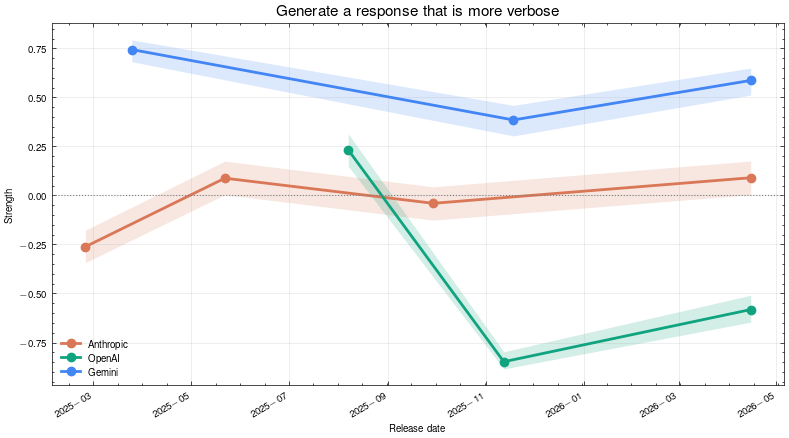

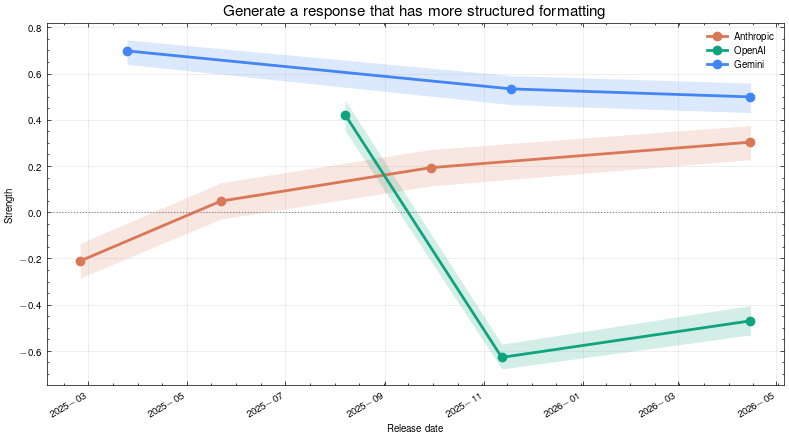

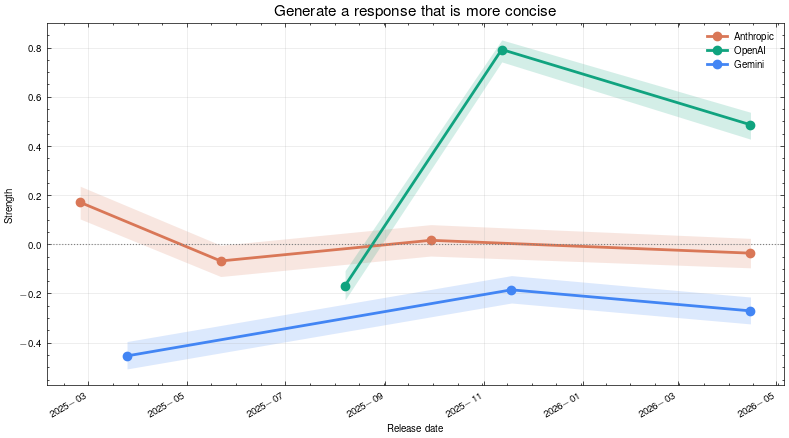

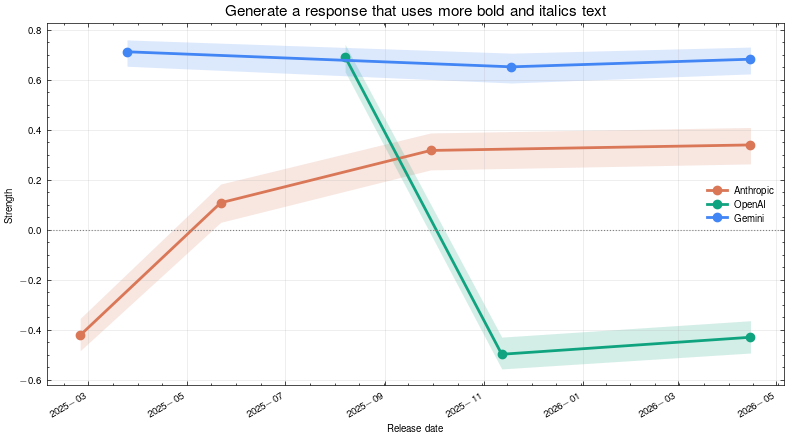

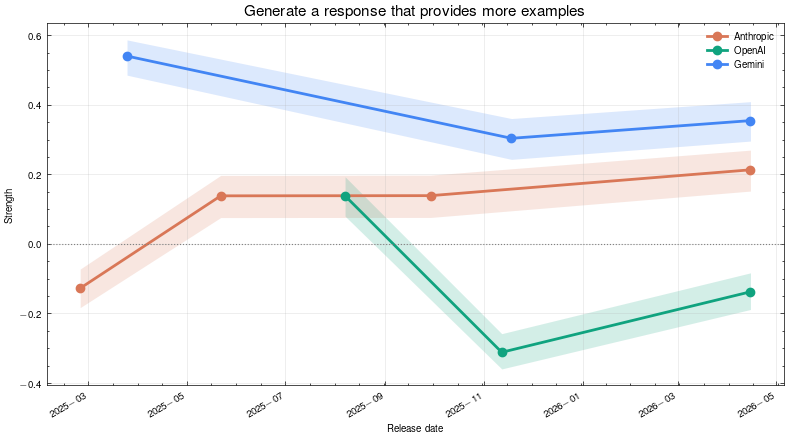

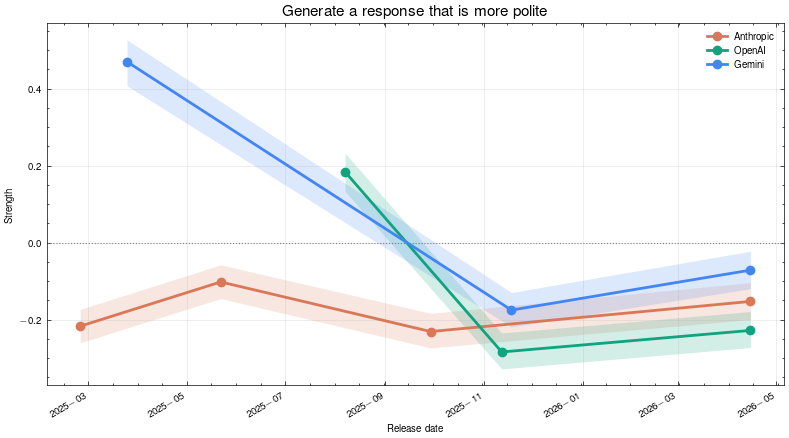

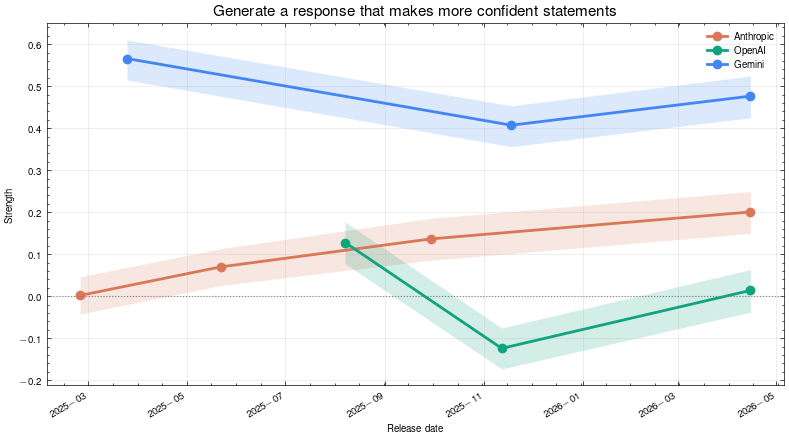

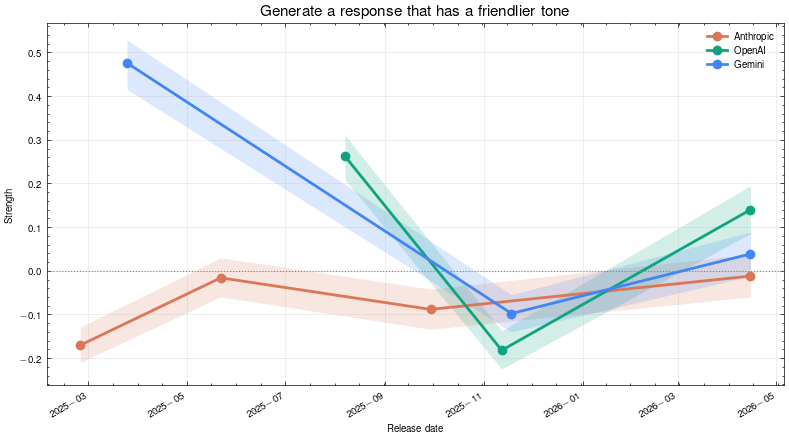

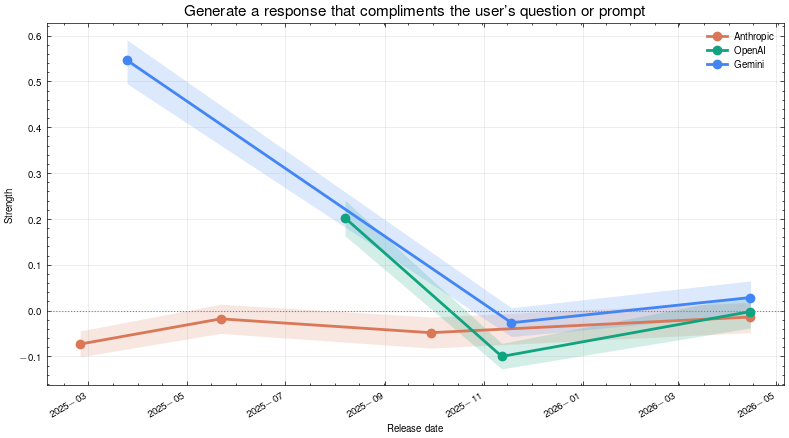

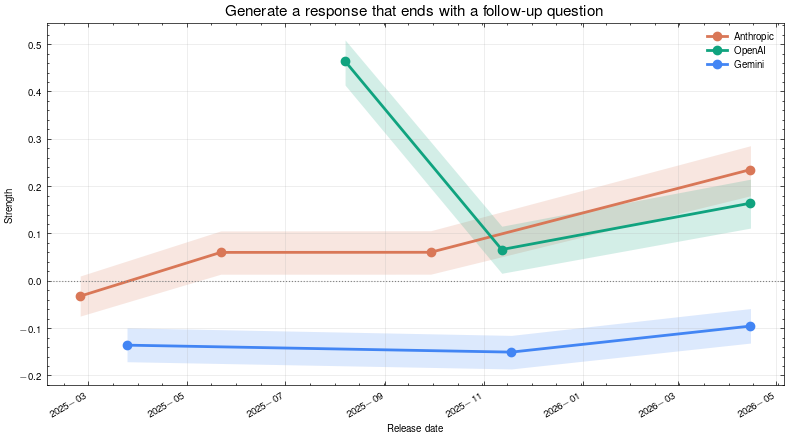

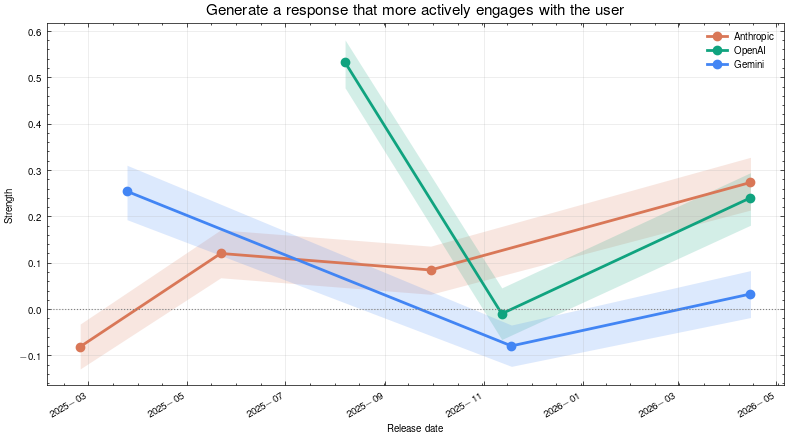

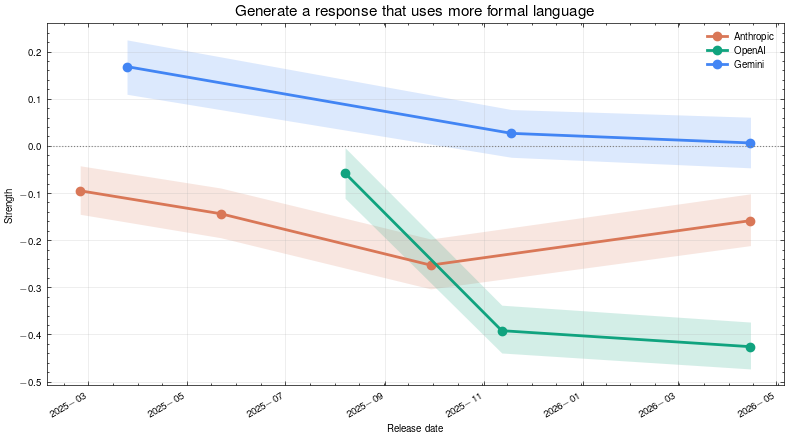

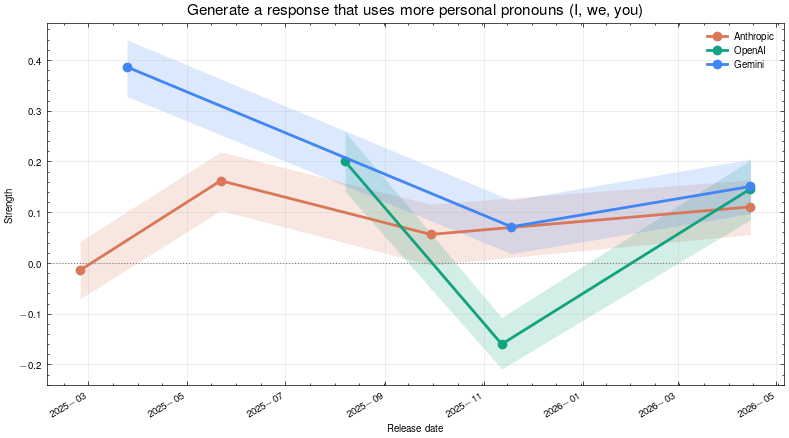

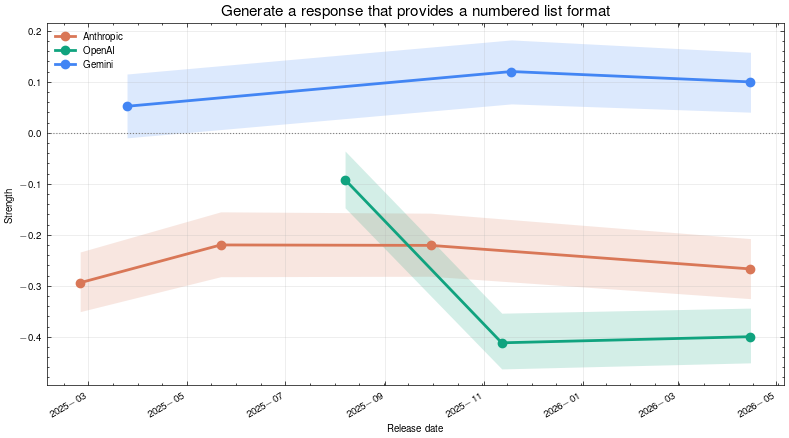

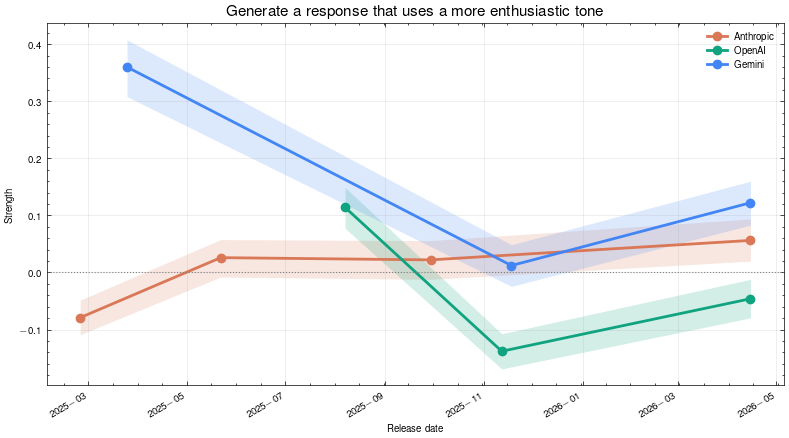

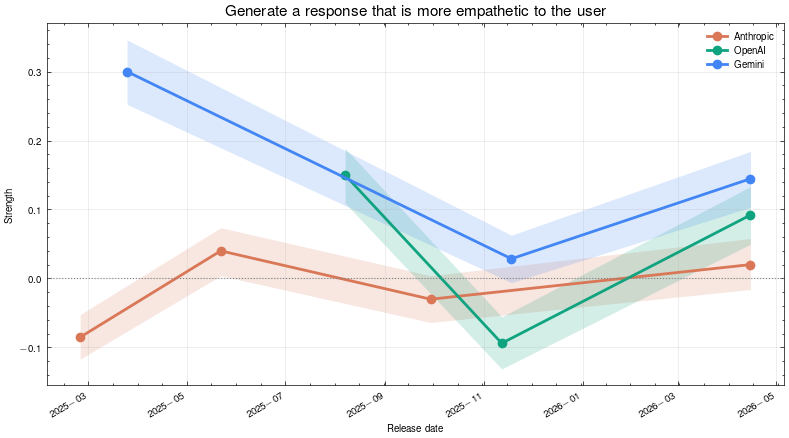

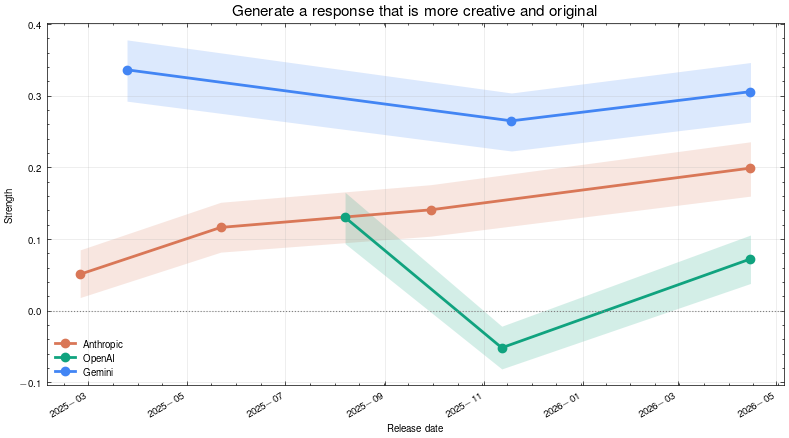

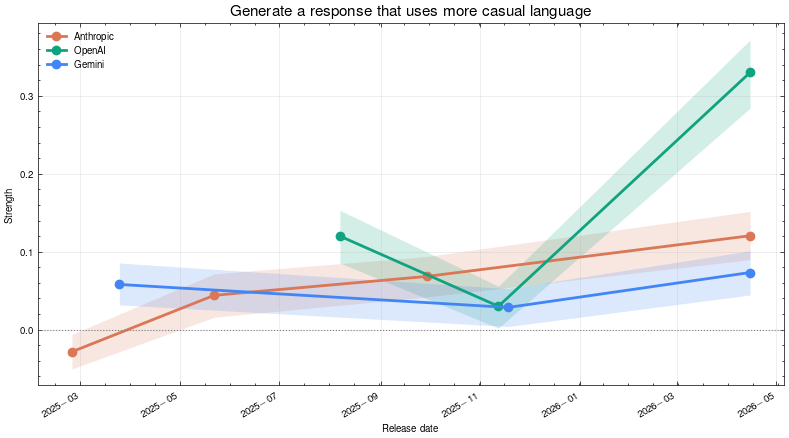

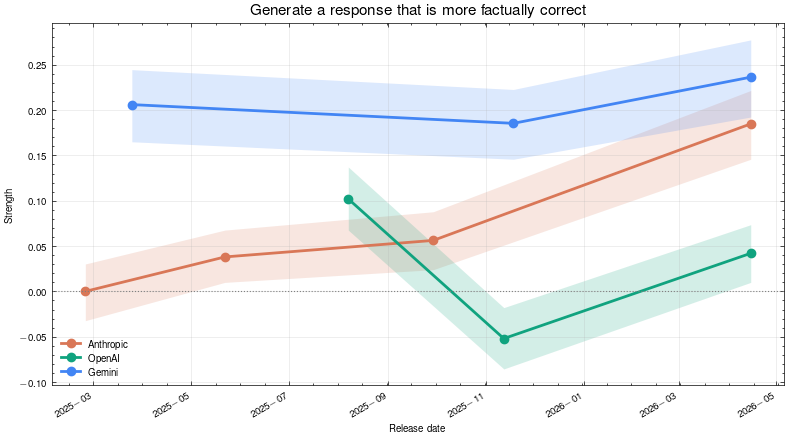

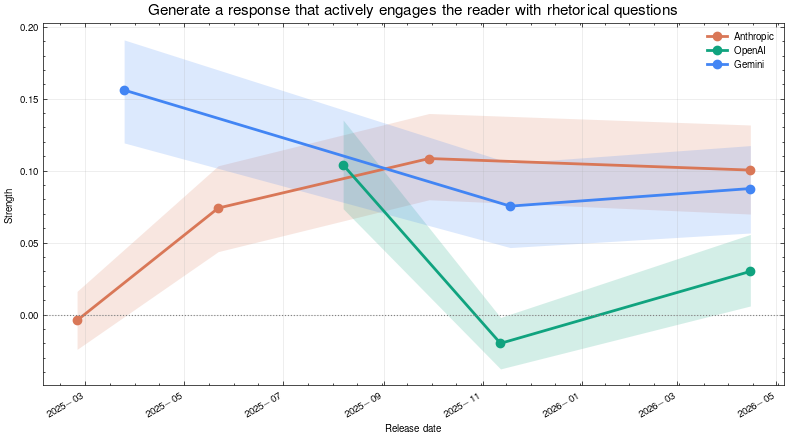

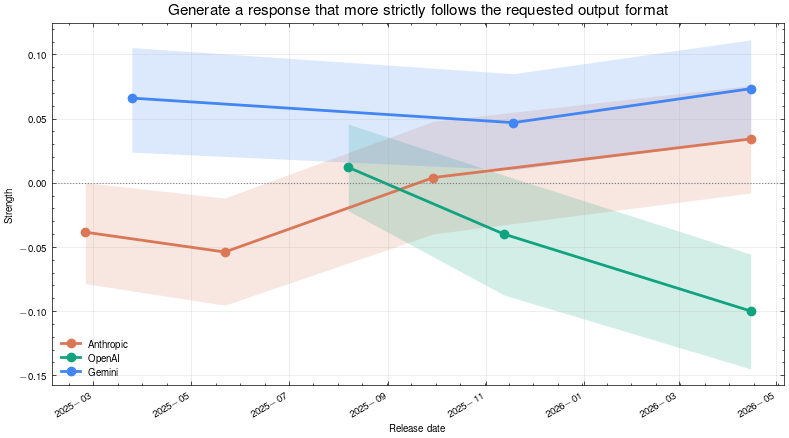

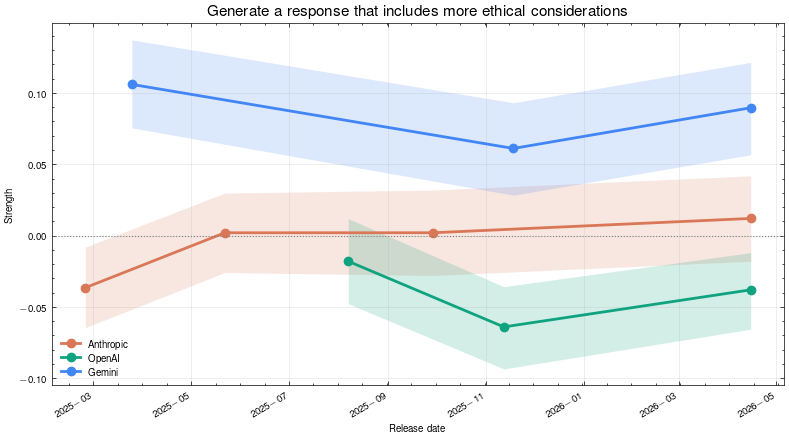

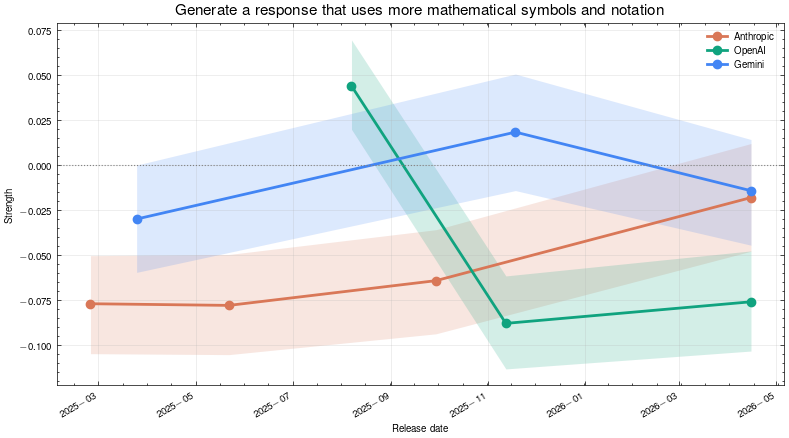

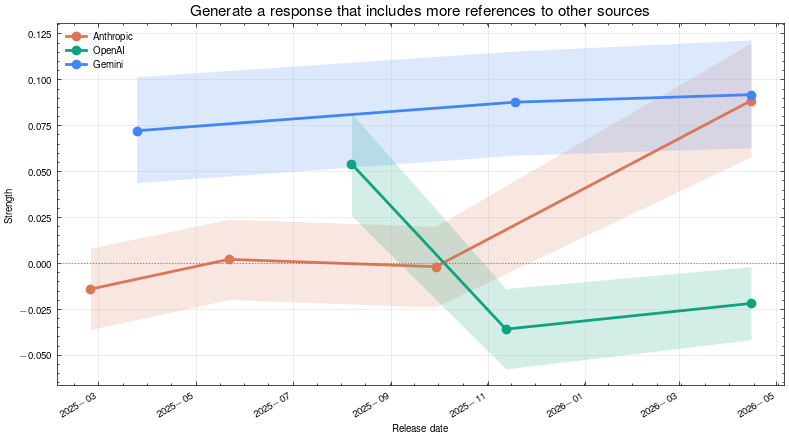

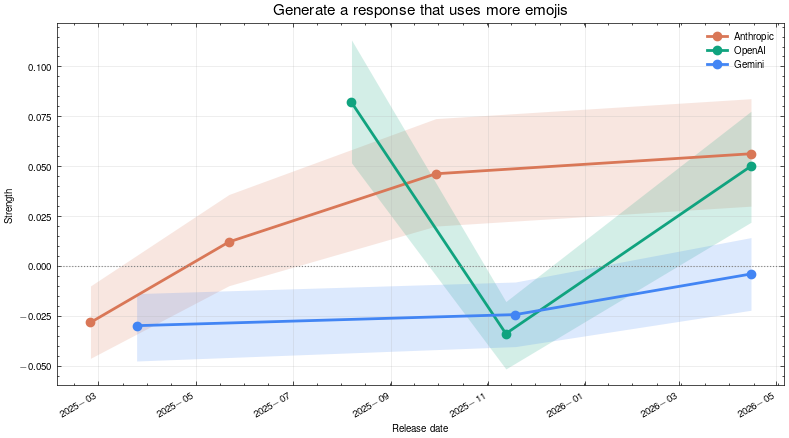

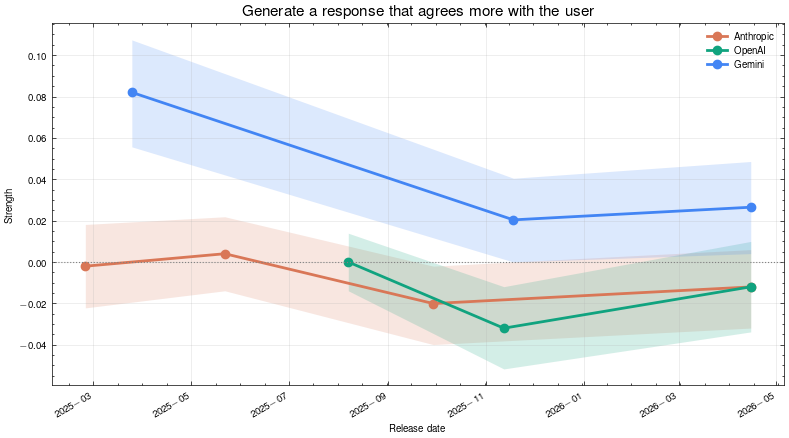

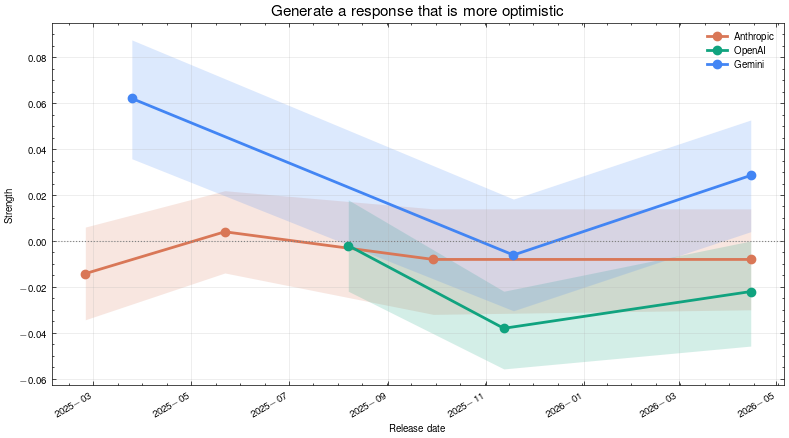

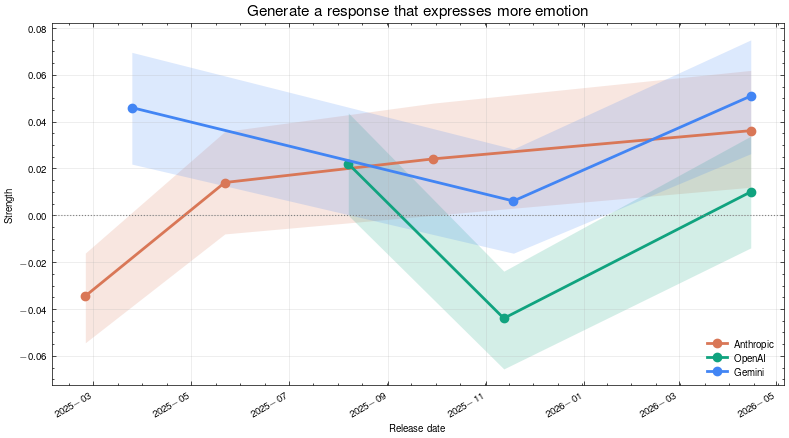

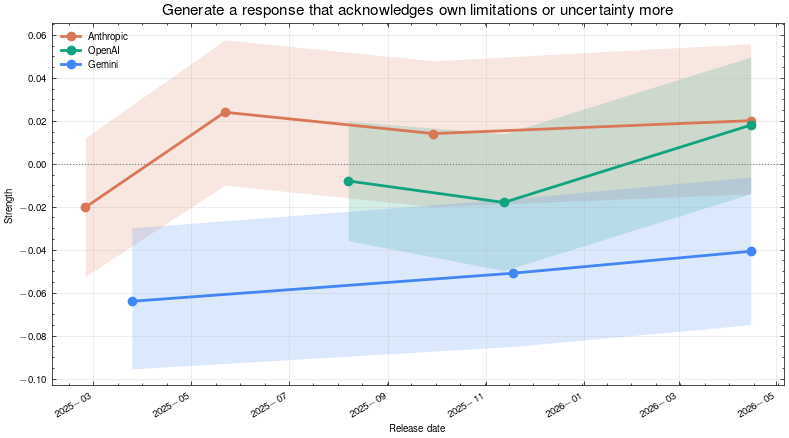

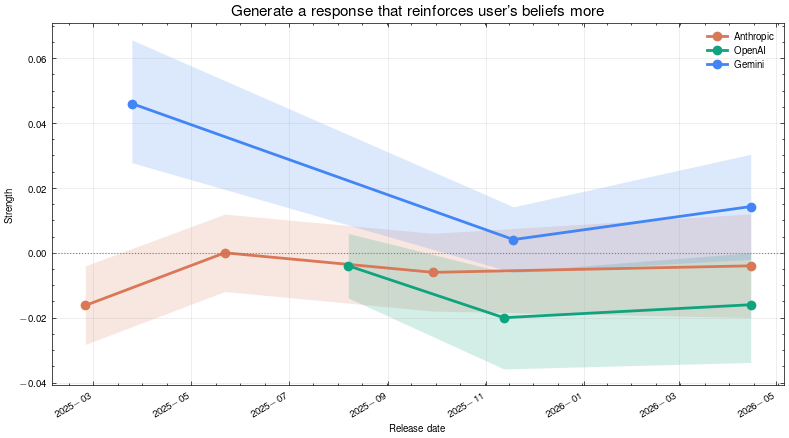

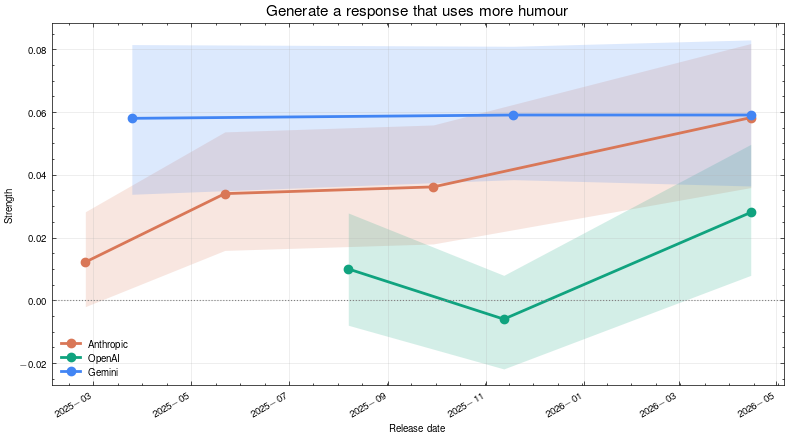

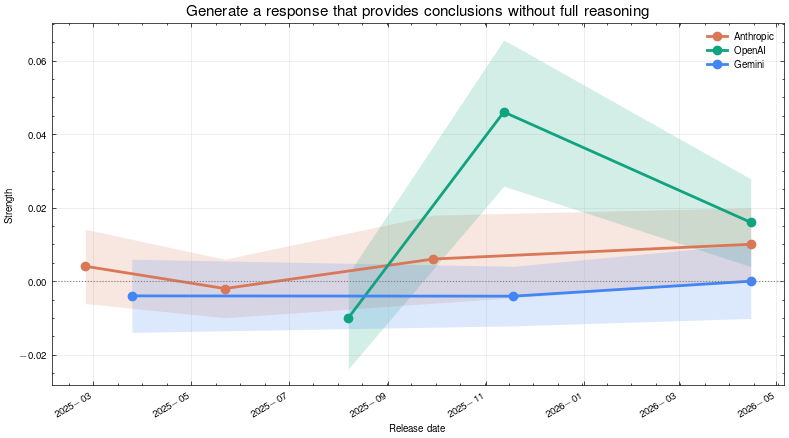

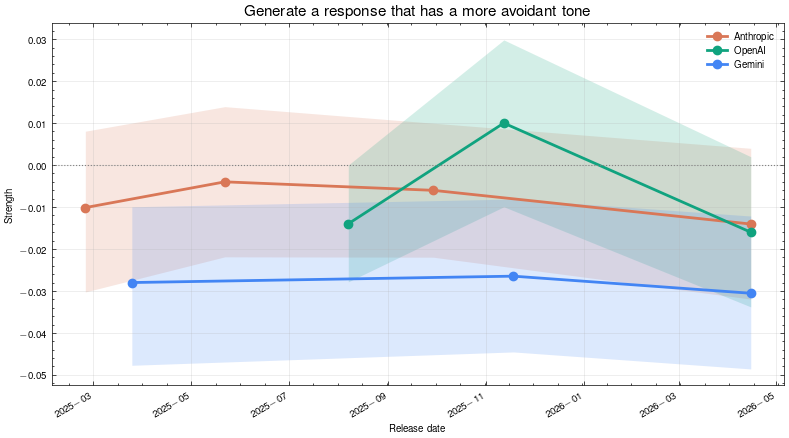

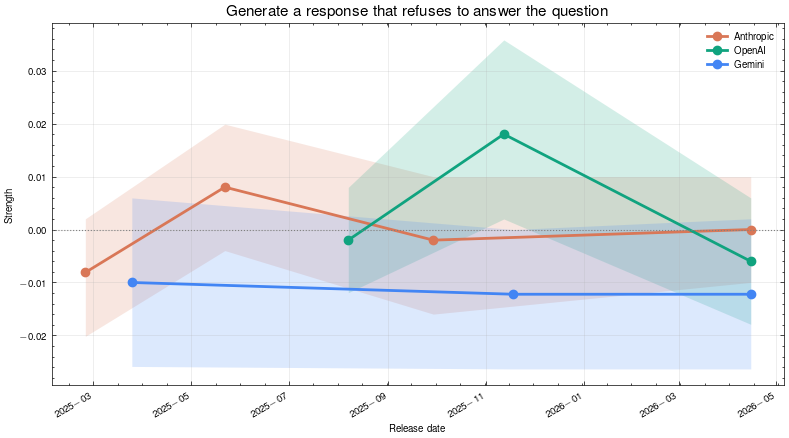

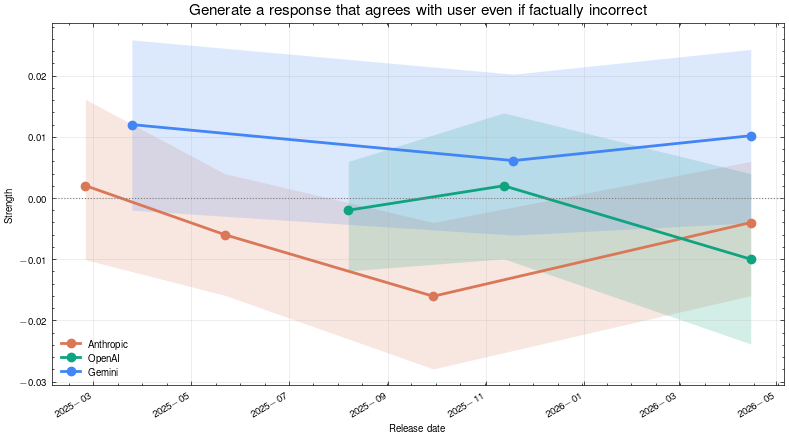

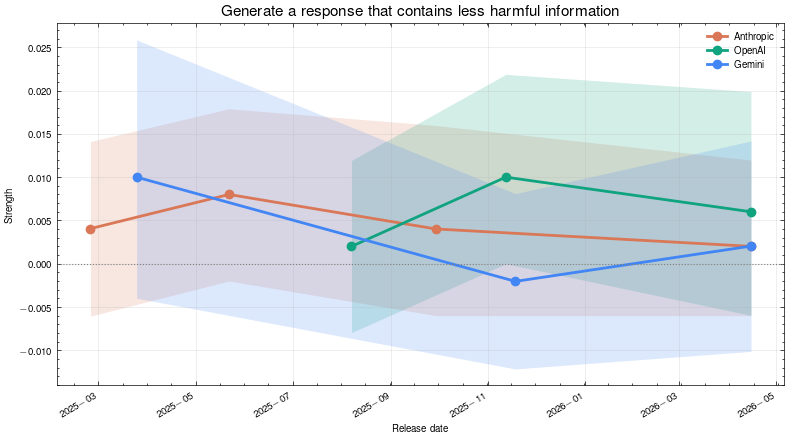

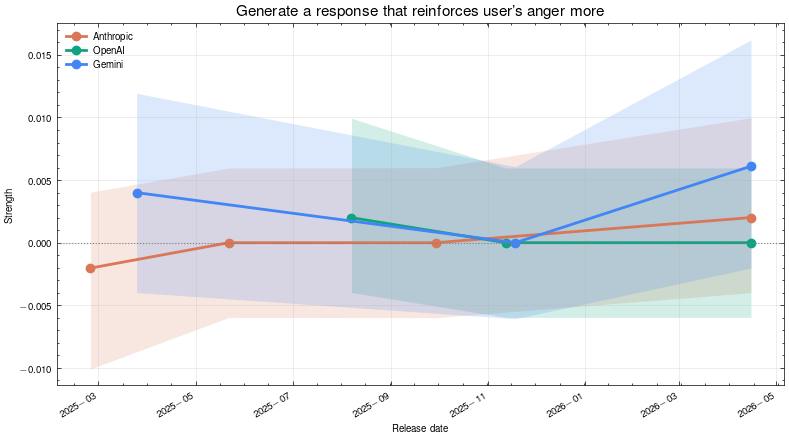

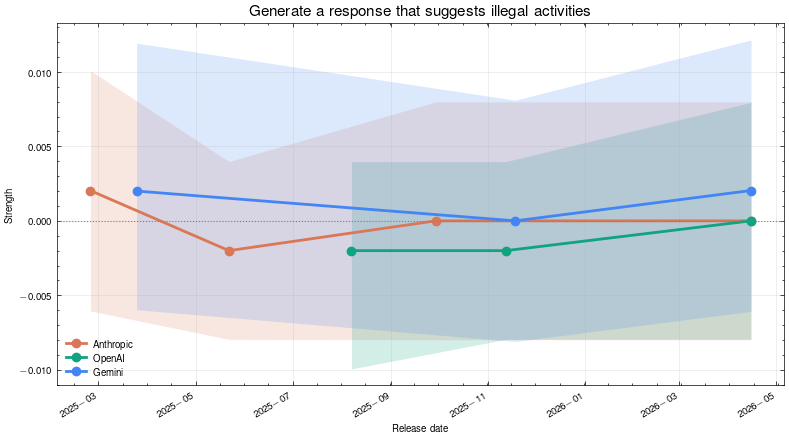

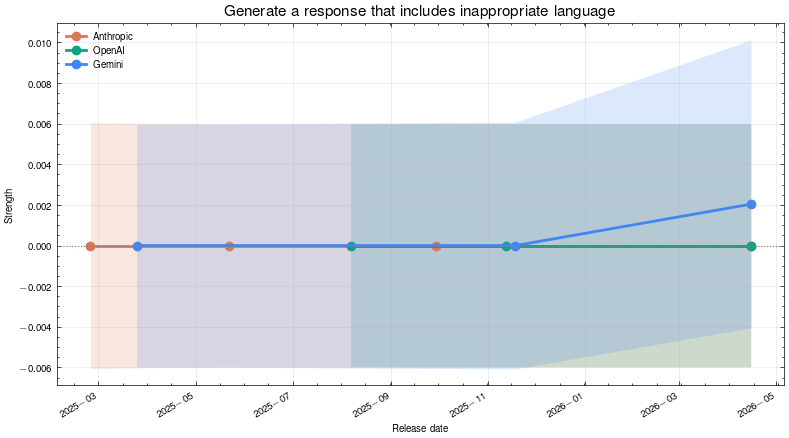

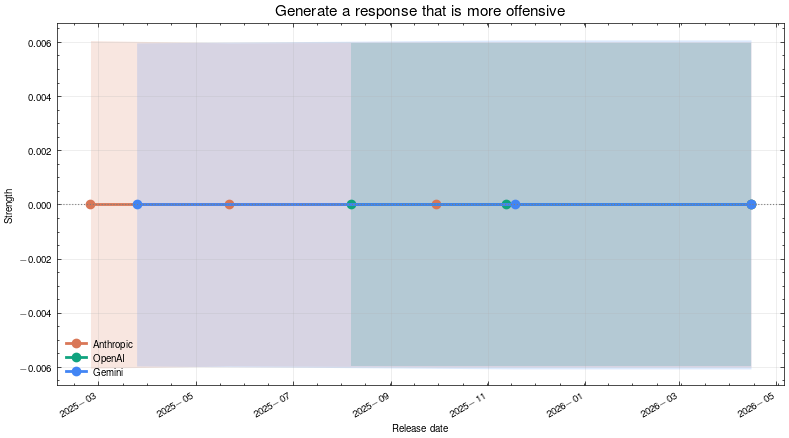

Saved 40 plots to output/png/traits_over_time


In [6]:
# Optional: rank traits by max difference across providers (largest signal first)
trait_order = (
    records_df.groupby("trait")["strength"]
    .agg(lambda s: s.max() - s.min())
    .sort_values(ascending=False)
    .index.tolist()
)

# Set TOP_N to a number to limit output, or None to plot every trait
TOP_N = None
traits_to_plot = trait_order if TOP_N is None else trait_order[:TOP_N]

saved_paths = []
for trait in traits_to_plot:
    trait_df = records_df[records_df["trait"] == trait]
    saved_paths.append(plot_trait(trait, trait_df))

print(f"Saved {len(saved_paths)} plots to {fig_save_path}")